# Asset Pricing

In [5]:
import numpy as np
import pandas as pd
import scipy.stats as si
import matplotlib.pyplot as plt
import yfinance as yf

# Set random seed for reproducibility across all simulations
np.random.seed(42)

In [6]:
class PortfolioOptimizer:
    """Generates random portfolios to map the Efficient Frontier."""
    def __init__(self, tickers, start_date="2024-01-01", end_date="2026-01-01"):
        data = yf.download(tickers, start=start_date, end=end_date)['Close']
        self.returns = data.pct_change().dropna()
        self.mean_returns = self.returns.mean() * 252  # Annualized
        self.cov_matrix = self.returns.cov() * 252      # Annualized
        self.tickers = tickers

    def simulate_portfolios(self, n_portfolios=10000, rf=0.04):
        num_assets = len(self.tickers)
        results = np.zeros((3, n_portfolios))
        weights_record = []

        for i in range(n_portfolios):
            weights = np.random.random(num_assets)
            weights /= np.sum(weights)  # Normalize to sum to 1
            weights_record.append(weights)
            
            # Portfolio Metrics
            p_return = np.sum(weights * self.mean_returns)
            p_std = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
            p_sharpe = (p_return - rf) / p_std
            
            results[0, i] = p_return
            results[1, i] = p_std
            results[2, i] = p_sharpe

        return results, weights_record

    def plot_frontier(self, results):
        max_sharpe_idx = np.argmax(results[2])
        sd_max, ret_max = results[1, max_sharpe_idx], results[0, max_sharpe_idx]

        plt.figure(figsize=(10, 6))
        sc = plt.scatter(results[1], results[0], c=results[2], cmap='viridis', marker='o', s=10, alpha=0.5)
        plt.colorbar(sc, label='Sharpe Ratio')
        plt.scatter(sd_max, ret_max, color='red', marker='*', s=200, label='Max Sharpe Portfolio')
        plt.title('Efficient Frontier Simulation')
        plt.xlabel('Annualized Volatility')
        plt.ylabel('Annualized Return')
        plt.legend()
        plt.grid(True)
        plt.show()

In [7]:
my_portfolio_tickers=["AAPL","AMD","NVDA","TSLA"]
opt = PortfolioOptimizer(tickers=my_portfolio_tickers, start_date="2024-01-01", end_date="2026-01-01")

[*********************100%***********************]  4 of 4 completed


In [15]:
sim_results, portfolio_weights = opt.simulate_portfolios(n_portfolios=10000, rf=0.04)

In [16]:
import numpy as np

# Find the column index of the highest Sharpe Ratio
max_sharpe_idx = np.argmax(sim_results[2])

# Grab the optimal metrics using that index
best_return = sim_results[0, max_sharpe_idx]
best_volatility = sim_results[1, max_sharpe_idx]
best_sharpe = sim_results[2, max_sharpe_idx]

# Grab the optimal weight distribution for our assets
best_weights = portfolio_weights[max_sharpe_idx]

# Print the results cleanly
print("=== OPTIMAL PORTFOLIO METRICS ===")
print(f"Expected Annual Return: {best_return:.2%}")
print(f"Expected Volatility (Risk): {best_volatility:.2%}")
print(f"Max Sharpe Ratio: {best_sharpe:.4f}\n")

print("=== OPTIMAL ASSET ALLOCATION ===")
for ticker, weight in zip(my_portfolio_tickers, best_weights):
    print(f"{ticker}: {weight:.2%}")

=== OPTIMAL PORTFOLIO METRICS ===
Expected Annual Return: 78.84%
Expected Volatility (Risk): 49.23%
Max Sharpe Ratio: 1.5202

=== OPTIMAL ASSET ALLOCATION ===
AAPL: 0.87%
AMD: 0.07%
NVDA: 93.28%
TSLA: 5.79%


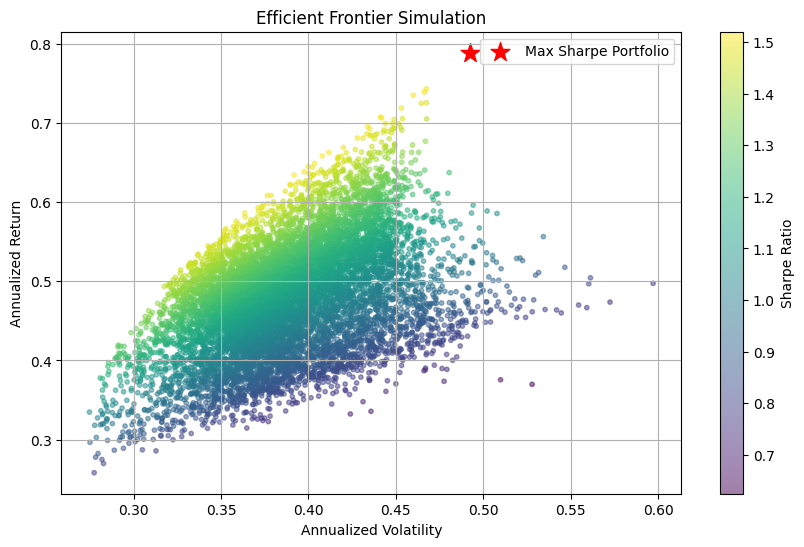

In [17]:
# Generate the interactive chart showing all 10,000 portfolios and the optimal star
opt.plot_frontier(sim_results)

# Liquidity at Risk


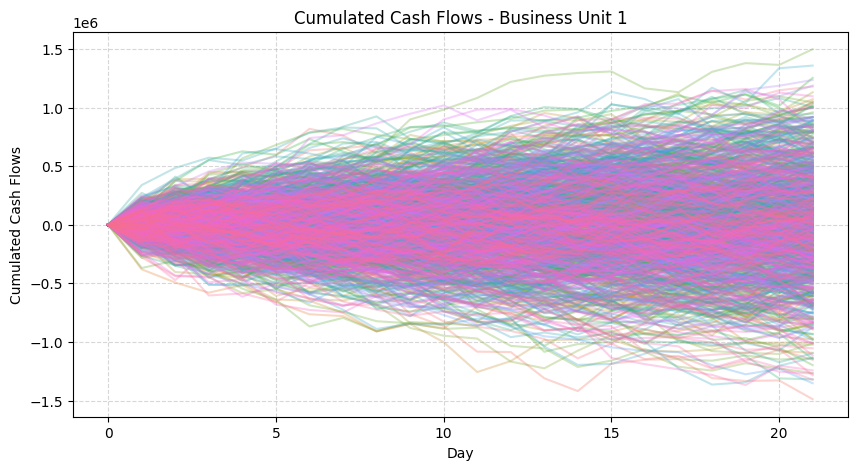

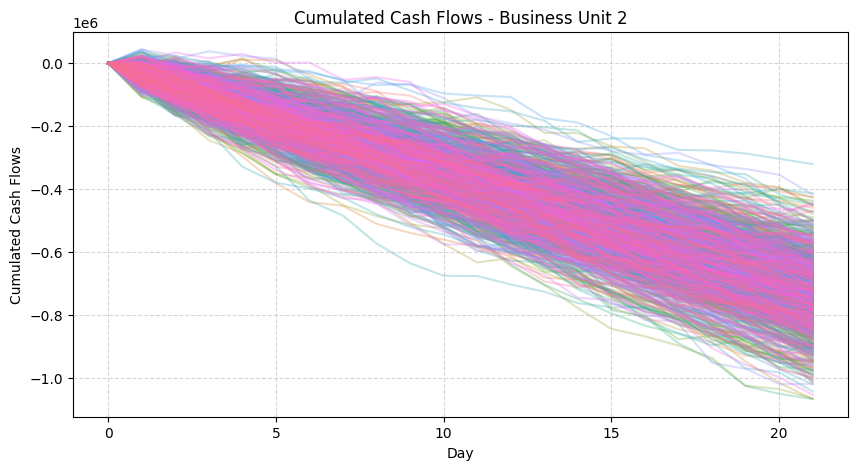

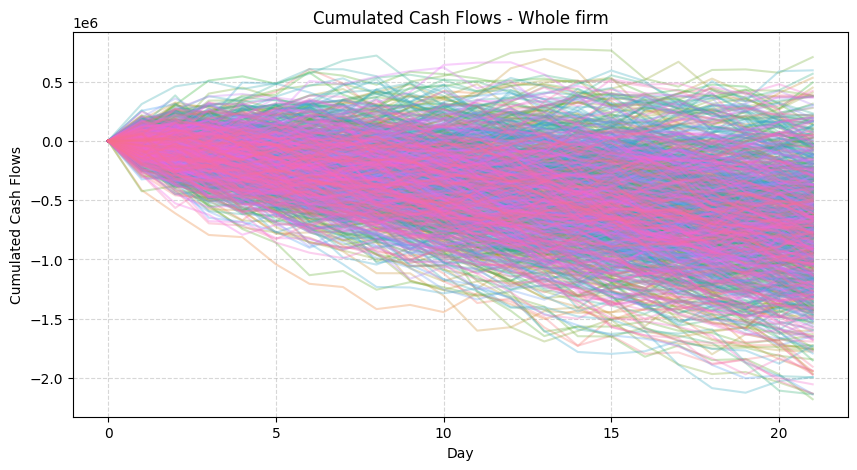

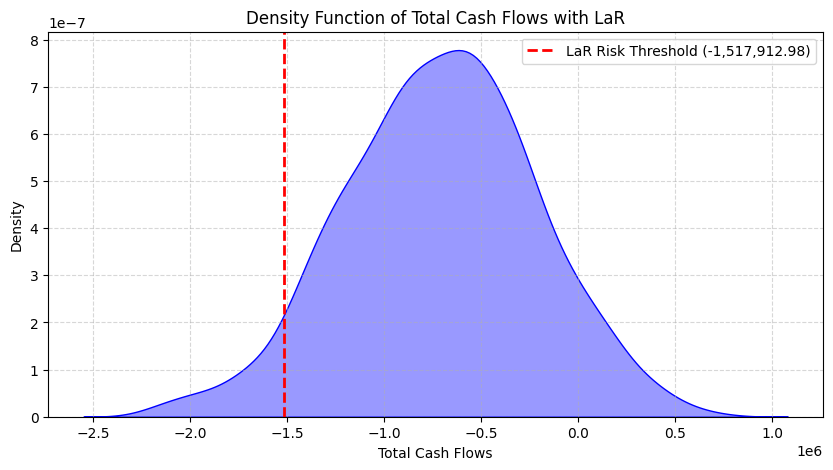

Monthly Liquidity at Risk (LaR) for the firm: 1,517,912.98


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(123)

# 1. Functions
def simulate_daily_cash_outflows(num_days, mean_outflow, sd_outflow):
    return np.random.normal(mean_outflow, sd_outflow, num_days)

def calculate_lar(total_cash_flows_series, alpha):
    # R's quantile(df, 1-alpha) maps to np.percentile or pd.quantile
    return total_cash_flows_series.quantile(1 - alpha)

# 2. Parameters
num_simulations = 1000
num_days_in_month = 21
total_elements = num_simulations * num_days_in_month
# Define mean and standard deviation for each business unit's daily cash outflows
mean_outflow_bu1, sd_outflow_bu1 = 0, 100000
mean_outflow_bu2, sd_outflow_bu2 = -35000, 25000

# 3. Simulate and shape data into DataFrames (Simulations as rows, Days as columns)
# Note: R fills matrices column-first by default. To match structure cleanly, 
# we shape directly into (num_simulations, num_days_in_month)
sim_bu1 = simulate_daily_cash_outflows(total_elements, mean_outflow_bu1, sd_outflow_bu1)
sim_bu2 = simulate_daily_cash_outflows(total_elements, mean_outflow_bu2, sd_outflow_bu2)

day_columns = [f"day{i}" for i in range(1, num_days_in_month + 1)]

df_bu1 = pd.DataFrame(sim_bu1.reshape(num_simulations, num_days_in_month), columns=day_columns)
df_bu2 = pd.DataFrame(sim_bu2.reshape(num_simulations, num_days_in_month), columns=day_columns)

# Add day0 = 0 at the beginning of the DataFrames
df_bu1.insert(0, 'day0', 0.0)
df_bu2.insert(0, 'day0', 0.0)

# 4. Calculate total daily cash outflows for the firm across all days (including day 0)
# Summing the dataframes together element-by-element, then summing across all days per simulation
total_cash_flows = (df_bu1 + df_bu2).sum(axis=1).to_frame(name='total_cash_flows')

# 5. Calculate cumulative cash flows (transposing to make Days the rows, Simulations as columns)
cum_bu1 = df_bu1.cumsum(axis=1).T
cum_bu2 = df_bu2.cumsum(axis=1).T

# Rename columns to match R's 'sim1', 'sim2', etc.
sim_columns = [f"sim{i}" for i in range(1, num_simulations + 1)]
cum_bu1.columns = sim_columns
cum_bu2.columns = sim_columns

# Reset index to create the 'day' column explicitly
cum_bu1 = cum_bu1.reset_index().rename(columns={'index': 'day'})
cum_bu2 = cum_bu2.reset_index().rename(columns={'index': 'day'})

# Convert the day string index (e.g., 'day0', 'day1') into integers (0, 1, 2...)
cum_bu1['day'] = range(len(cum_bu1))
cum_bu2['day'] = range(len(cum_bu2))

# Create total cumulative data frame for the whole firm
cum_firm = cum_bu1.copy()
# Sum the numerical simulation columns together
cum_firm[sim_columns] = cum_bu1[sim_columns] + cum_bu2[sim_columns]

# ==============================================================================
# PLOTTING (ggplot2 equivalents using Matplotlib & Seaborn)
# ==============================================================================

# Helper function to melt data and plot lines
def plot_cumulative_flows(df, title):
    plt.figure(figsize=(10, 5))
    # Melt dataframe from wide format to long format
    df_melted = df.melt(id_vars='day', var_name='simulation', value_name='CCF')
    # Using lineplot without hue legend to match R's guides(color="none")
    sns.lineplot(data=df_melted, x='day', y='CCF', hue='simulation', legend=False, alpha=0.3)
    plt.title(title)
    plt.xlabel("Day")
    plt.ylabel("Cumulated Cash Flows")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Plot Business Unit 1
plot_cumulative_flows(cum_bu1, "Cumulated Cash Flows - Business Unit 1")

# Plot Business Unit 2
plot_cumulative_flows(cum_bu2, "Cumulated Cash Flows - Business Unit 2")

# Plot Whole Firm
plot_cumulative_flows(cum_firm, "Cumulated Cash Flows - Whole firm")

# 6. Calculate Liquidity at Risk (LaR)
# Sorting the results to match R code step (even though quantile doesn't strictly require explicit pre-sorting)
total_cash_flows = total_cash_flows.sort_values(by='total_cash_flows').reset_index(drop=True)
raw_lar = calculate_lar(total_cash_flows['total_cash_flows'], 0.95)
LaR = abs(raw_lar)

# Plot Density Function with LaR Line
plt.figure(figsize=(10, 5))
sns.kdeplot(data=total_cash_flows, x='total_cash_flows', fill=True, color='blue', alpha=0.4)
plt.axvline(x=raw_lar, color='red', linestyle='--', linewidth=2, label=f'LaR Risk Threshold ({raw_lar:,.2f})')
plt.title("Density Function of Total Cash Flows with LaR")
plt.xlabel("Total Cash Flows")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Print Final Metric
print(f"Monthly Liquidity at Risk (LaR) for the firm: {LaR:,.2f}")

In [20]:
df_bu1

,day0,day1,day2,day3,day4,day5,day6,day7,day8,day9,...,day12,day13,day14,day15,day16,day17,day18,day19,day20,day21
0,0.0,-108563.060330,99734.544658,28297.849805,-150629.471392,-57860.025197,165143.653710,-242667.924339,-42891.262886,126593.625871,...,-9470.896894,149138.962612,-63890.199668,-44398.195965,-43435.127562,220593.008273,218678.608897,100405.389788,38618.639917,73736.857590
1,0.0,149073.202815,-93583.386840,117582.904478,-125388.066775,-63775.150245,90710.519580,-142868.070023,-14006.872019,-86175.489586,...,-177153.310451,-69987.723460,92746.243176,-17363.568279,284.591590,68822.271110,-87953.634301,28362.732381,-80536.651807,-172766.949412
2,0.0,-39089.979376,57380.586241,33858.905100,-1183.049448,239236.526594,41291.216031,97873.600594,223814.333850,-129408.532316,...,-79806.273524,2968.323030,106931.596942,89070.639129,175488.618198,149564.413703,106939.266971,-77270.871425,79486.266779,31427.199451
3,0.0,-132626.545994,141729.904648,80723.653458,4549.008063,-23309.206098,-119830.114470,19952.407356,46843.911945,-83115.498424,...,-212310.035004,103972.709089,-40336.603810,-12602.958531,-83751.672283,-160596.276072,125523.737472,-68886.898385,166095.248815,80730.818621
4,0.0,-31475.814672,-108590.240113,-73246.198672,-121252.313110,208711.335959,16444.123023,115020.554255,-126735.204901,18103.512960,...,103111.445892,-108456.791201,-136347.154462,37940.061208,-37917.643457,64205.468927,-197788.793152,71226.463547,259830.392727,-2462.598143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,-114187.996131,-6352.198088,5889.891295,13135.770798,-77083.947390,-116793.332672,-67445.354302,62626.813642,-87196.573215,...,27685.870427,-40722.845239,-44013.460629,-102367.706788,-31049.414673,59573.519062,-49845.791457,-88236.705637,-171977.760868,126838.478048
996,0.0,126885.409729,-328750.631924,76964.469632,-170387.143723,-79222.675916,2617.401208,82883.879986,-8416.421048,-2602.477953,...,-181398.485565,-64937.421235,-24617.373616,-46856.236750,43706.518106,-205047.051581,126729.312520,-12911.497008,151474.744082,81224.920870
997,0.0,-160.078546,81567.154936,34681.029199,253.477531,-54070.565853,57320.986862,42242.587804,41997.744605,63657.815225,...,52567.149476,-64246.819443,96101.704088,85133.804504,-128062.459144,105388.818472,28816.505096,-155215.506316,-103721.433894,-15261.467624
998,0.0,126542.403944,130828.745561,64751.858284,13480.089536,-64788.938232,-85031.495974,42926.551163,22584.387202,-36912.239810,...,-32255.463104,176750.262162,-112965.190688,159759.590630,74095.908439,29933.489107,38165.349693,72204.223769,40657.980338,31790.765822


In [21]:
df_bu2

,day0,day1,day2,day3,day4,day5,day6,day7,day8,day9,...,day12,day13,day14,day15,day16,day17,day18,day19,day20,day21
0,0.0,-15095.238839,-5351.054814,-27449.109134,-84961.598632,-5090.768215,-49619.758889,-15327.801691,-19569.602396,-26921.624578,...,29924.930147,-87652.330050,-559.075390,-25257.462408,-69692.217277,-30433.893753,-26012.783534,-15220.372165,-8578.253384,-39433.008034
1,0.0,-52562.800054,-88561.371833,-59778.371830,-34522.470531,-47787.051791,-50292.166855,-16657.214742,-17017.255549,-59348.429046,...,-53362.632261,-14960.727780,-2195.237715,-21002.915948,-37926.231617,-56842.770978,-22258.704356,-43236.519538,-14166.358930,-35621.973570
2,0.0,-5123.619433,155.651161,-43822.689876,-74228.432724,-41408.567173,-59627.387383,-34243.140824,-50388.101622,-74970.501751,...,-74044.822240,-37496.065523,-6671.192483,-2587.368650,6965.027329,-44356.607836,-72641.109626,-28949.203988,-28231.731970,-29420.736424
3,0.0,-38017.854225,-65656.998477,-82169.033514,-35638.685454,-73991.536244,-37555.431813,-59736.357544,-48455.672506,-19232.906623,...,-15877.040511,-64848.542997,-14490.250009,-20673.202920,-56858.756720,-49616.331090,-18563.796181,-41624.628436,-57865.620151,-54437.826392
4,0.0,-25321.732103,-8640.881580,-32560.672324,-674.110142,-61063.491626,-34935.006308,-40815.367372,-36057.178262,-59045.414786,...,-17654.387946,8730.966115,10240.850655,-11413.528835,5561.264277,-70837.485910,-74675.082058,-18378.205943,-10093.363947,-66418.399696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,-76062.666028,-22113.532619,9576.321288,-37808.401304,-27609.912068,-56978.632409,15620.042597,-46181.294875,-21288.262789,...,-34424.456839,-32247.923058,-72895.997766,-21425.053181,-10338.769293,-3266.443861,-12879.760055,-16477.180342,-39836.041266,-18533.471486
996,0.0,-63364.991587,10773.032706,-38183.132455,-54582.381196,-18195.037138,-54892.100218,-8959.548388,-12598.316016,-17566.048083,...,-44864.430539,-64589.632449,6526.833306,-36930.507900,-29992.321674,-61346.289096,-69401.698045,-8877.822614,-22895.512165,-18537.100998
997,0.0,-1755.534054,-43380.872119,-69488.373632,-45514.225759,-59803.209620,-19618.375685,-94219.656573,-34451.418482,-35693.384729,...,-37785.855173,-42827.196441,-61428.876309,-59356.068273,-72940.431552,-28017.872017,30861.672065,-40716.307022,-418.945273,-43416.483176
998,0.0,-13578.422696,-32166.799326,-31196.633157,-34002.508338,-33243.431791,-49414.087772,5555.363176,-30793.745341,-75829.849574,...,-44225.805332,-24566.537598,20924.075809,-45857.003120,-14963.558209,35551.958643,-18513.515230,-25119.596787,-21365.001032,-48996.957386


# Finding Value at Risk

In [22]:
import numpy as np
import pandas as pd

# 1. Replace these numbers with your actual 30-day Profit/Loss data
# (Negative numbers = losses, Positive numbers = profits)
pnl_data = [
    1200, -450, 800, -1500, 300, -2100, 600, -100, 150, -850,
    900, -300, 400, -1200, 50, -500, 1100, -200, 750, -950,
    1300, 200, -600, -1350, 450, -50, 950, -400, 1050, -700
]

# Convert to a Pandas Series
df_pnl = pd.Series(pnl_data)

# 2. Calculate the 5th percentile
# 5% VaR corresponds to the 5th percentile of your P&L distribution
var_5_pct = df_pnl.quantile(0.05)

print(f"The 5% Value-at-Risk threshold is: {var_5_pct:,.2f}")
print(f"Interpretation: You have a 5% chance of losing ${abs(var_5_pct):,.2f} or more in a single day.")

The 5% Value-at-Risk threshold is: -1,432.50
Interpretation: You have a 5% chance of losing $1,432.50 or more in a single day.


### Calculating 5% Value-at-Risk (VaR) via Historical Simulation

To find the 5% VaR using a 30-day historical window of Profit and Loss (P&L), we track how our worst historical days look without assuming a standard bell-curve distribution.

---

#### Step 1: Gather and Sort Your Data
Take your 30 daily P&L numbers and sort them sequentially from the worst loss (most negative) to the best profit (most positive). 

#### Step 2: Find the 5% Cutoff Position
To locate the exact threshold representing our 5% tail risk, apply the position formula:

$$\text{Position} = \text{Total Days} \times \text{VaR Percentage}$$
$$\text{Position} = 30 \times 0.05 = 1.5$$

Since position 1.5 sits directly between your 1st worst day and your 2nd worst day, standard institutional practice is to average those two worst days, or use the second worst day as a conservative risk baseline.

#### Step 3: Interpret the Metric
If your second worst day in the sequence was a loss of -\$1,200, your 5% VaR is \$1,200.

There is a 5% statistical probability (roughly 1.5 days out of 30) that your portfolio will lose \$1,200 or more tomorrow. Flip that around, and you can say with 95% confidence that your daily losses will be milder than \$1,200.